# One-Phonon Diffuse Scattering: Rigid-Body Model for Triclinic Lysozyme (6O2H)

**Goal:** Compute the one-phonon (thermal diffuse) scattering intensity $I_{\text{TDS}}(\mathbf{q})$
for a crystal in which the entire protein (plus tightly bound solvent) is treated as a single rigid body.

**Inputs you provide:**
- `6o2h.cif` — PDB coordinate file (downloaded once, cell below)
- `6o2h-sf.cif` — Structure-factor CIF with experimental amplitudes *(optional — only needed for Option B density)*
- A callable `dynamical_matrix(q_cart, hkl)` that returns the $6\times6$ mass-weighted
  dynamical matrix $D(\mathbf{q})$ for a given Cartesian wavevector
  $\mathbf{q}$ (Å$^{-1}$) and Miller index triple.

**Key formula (classical high-$T$ limit):**
$$
I_{\text{TDS}}(\mathbf{q}) = k_BT\;\mathbf{G}^\dagger(\mathbf{q})\, D^{-1}(\mathbf{q})\, \mathbf{G}(\mathbf{q})
$$
where the 6-component coupling vector is
$$
\mathbf{G}(\mathbf{q}) = \begin{pmatrix} i\mathbf{q}\, F(\mathbf{q}) \\ i\mathbf{q}\times \mathbf{L}(\mathbf{q}) \end{pmatrix},
\qquad
\mathbf{L}(\mathbf{q}) = \mathbf{P}(\mathbf{q}) - \mathbf{r}_{\text{cm}}\,F(\mathbf{q})
$$
and $F(\mathbf{q})$, $\mathbf{P}(\mathbf{q})$ are the zeroth- and first-moment
structure factors of the masked electron density, computed via FFT.

**Sections:**
1. Setup & Downloads
2. Load Structure with gemmi
3. Build Electron Density (choose Option A or B)
4. Solvent Masking
5. Center of Mass
6. Reciprocal-Space Grid & FFT
7. Coupling Vector $\mathbf{G}(\mathbf{q})$
8. Dynamical Matrix Interface
9. One-Phonon TDS — Classical Limit
10. One-Phonon TDS — Quantum Formula
11. Quick Visualization


## 1 · Setup & Downloads

In [1]:
import numpy as np
import gemmi
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from pathlib import Path

# Physical constants (SI, then useful derived values)
kB_J   = 1.380649e-23    # J/K
hbar_J = 1.054571817e-34 # J·s
T      = 300.0           # K
kT_J   = kB_J * T       # J  — insert same energy units as your D(q)

# ── Unit choices ─────────────────────────────────────────────────────
# Throughout this notebook:
#   distances  : Å
#   angles     : rad
#   q-vectors  : Å⁻¹  (with the 2π factor, physics convention)
#   density    : e/Å³
#   F(q)       : e   (electrons)
#   P(q)       : e·Å
#   G_T(q)     : e/Å   (translational coupling)
#   G_R(q)     : e     (rotational coupling)
#   D(q) TT block : [energy/Å²]   (translational stiffness)
#   D(q) RR block : [energy/rad²] (rotational stiffness)
#   D(q) TR block : [energy/Å]
#   I_TDS      : e²   (proportional to photon count / solid angle)
# ─────────────────────────────────────────────────────────────────────
print("gemmi version:", gemmi.__version__)


gemmi version: 0.7.5


In [2]:
# ── Download files from PDB (run once) ──────────────────────────────
COORD_CIF = Path("6o2h.cif")
SF_CIF    = Path("6o2h-sf.cif")   # needed for Option B (experimental density)

import urllib.request

if not COORD_CIF.exists():
    print("Downloading coordinate CIF…")
    urllib.request.urlretrieve(
        "https://files.rcsb.org/download/6o2h.cif", COORD_CIF
    )
    print("  →", COORD_CIF)
else:
    print("Using existing", COORD_CIF)

if not SF_CIF.exists():
    print("Downloading structure-factor CIF…")
    urllib.request.urlretrieve(
        "https://files.rcsb.org/download/6o2h-sf.cif", SF_CIF
    )
    print("  →", SF_CIF)
else:
    print("Using existing", SF_CIF)


Using existing 6o2h.cif
Using existing 6o2h-sf.cif


## 2 · Load Structure with gemmi

We read the coordinate CIF, inspect the unit cell and space group, and
optionally expand a higher-symmetry structure to P1 so that the
`DensityCalculatorX` fills the whole unit cell.


In [3]:
st = gemmi.read_structure(str(COORD_CIF))
st.remove_alternative_conformations()   # keep only the A conformation
st.remove_hydrogens()                   # optional: skip H for speed/clarity
st.remove_waters()                      # optional: keep only protein/ligand

cell = st.cell
sg   = st.find_spacegroup()
print(f"PDB entry    : {st.name}")
print(f"Space group  : {sg.hm}  (#{sg.number})")
print(f"Unit cell    : a={cell.a:.3f}  b={cell.b:.3f}  c={cell.c:.3f} Å")
print(f"              α={cell.alpha:.3f}  β={cell.beta:.3f}  γ={cell.gamma:.3f}°")
print(f"Volume       : {cell.volume:.1f} Å³")

# Count atoms
n_atoms = sum(1 for m in st for ch in m for r in ch for a in r)
print(f"Atoms loaded : {n_atoms}")


PDB entry    : 6O2H
Space group  : P 1  (#1)
Unit cell    : a=27.424  b=32.134  c=34.513 Å
              α=88.657  β=108.460  γ=111.877°
Volume       : 26616.9 Å³
Atoms loaded : 1030


In [4]:
# ── Expand to P1 if needed ───────────────────────────────────────────────────
# DensityCalculatorX can handle any space group by calling symmetrize_sum()
# after add_model_density_to_grid(), which is cleaner than explicit expansion.
# We do need the FULL unit cell for the rigid-body calculation, so we rely on
# symmetrize_sum() below.  For record-keeping, set the working spacegroup:

WORKING_SG = "P 1"

if sg.number != 1:
    print(f"Note: space group is {sg.hm}, not P1.")
    print("DensityCalculatorX will expand via symmetrize_sum().")
else:
    print("Structure is already in P1 — no expansion needed.")


Structure is already in P1 — no expansion needed.


## 3 · Build Electron Density

You have two options for the electron density $\rho(\mathbf{r})$, and they are
*not* the same thing.  Choose the one that matches your physical goal.

---

### Option A — Model density via `DensityCalculatorX` (IT92 form factors)

`gemmi.DensityCalculatorX` places atomic scattering form factors from the
IT92 tables onto a real-space grid, applying individual atomic B-factors from
the refined model.  The FFT of this density gives the *calculated* structure
factors $F_{\text{calc}}(\mathbf{q})$.

**Pros:**
- Complete: every voxel is filled, no missing Bragg reflections.
- Smooth: no Fourier truncation ripples.
- Reproduces exactly what your refined model says the electron density is.

**Cons:**
- Does not include any information beyond what is in the atomic model
  (no unmodeled disorder, no solvent scattering).
- Deviates from experiment wherever the model is imperfect.

---

### Option B — Hybrid density: experimental amplitudes + model phases

X-ray diffraction measures *intensities* $I(\mathbf{h}) \propto |F(\mathbf{h})|^2$,
not the complex $F$ itself.  **The phase is lost** — this is the crystallographic
"phase problem."  PDB SF-CIFs typically deposit only the raw measured amplitudes;
the phase must always be inferred from an atomic model.

The standard solution (and what every 2Fo-Fc map uses) is:
$$
F_{\text{hybrid}}(\mathbf{h}) = F_{\text{meas}}(\mathbf{h})\;e^{i\,\phi_{\text{calc}}(\mathbf{h})}
$$
This keeps the experimental amplitude — which encodes the *true* thermal and static
disorder of the crystal — while borrowing the phase from the refined model.

Option B implements this by:
1. Computing $\phi_{\text{calc}}(\mathbf{h})$ from the `DensityCalculatorX` grid via FFT.
2. Loading $F_{\text{meas}}$ from the SF-CIF.
3. Scattering $F_{\text{hybrid}}$ back onto a grid and FFT-ing to real space.

**Pros:**
- Amplitudes are experimentally constrained — more faithful to real disorder than IT92.
- Direct connection to the measured Bragg data.

**Cons:**
- Reflections absent from the SF-CIF (not measured, rejected) contribute zero →
  Fourier truncation ripples near sharp edges.  Usually small compared to the signal.
- Phases still come from the model; the "phase problem" is not solved, only mitigated.
- Requires running `DensityCalculatorX` at the data resolution to get phases.

---

**For diffuse scattering physics, Option B is generally preferable** because the
coupling vector $\mathbf{G}(\mathbf{q})$ should reflect the crystal's true electron
density.  Use Option A for a noise-free, model-consistent baseline or when the SF-CIF
is unavailable.

Run **one** of the two option cells below, then continue from Section 4.


In [5]:
# ════════════════════════════════════════════════════════════════════
# OPTION A: Model density from DensityCalculatorX (IT92 form factors)
# ════════════════════════════════════════════════════════════════════
# Skip this cell and run the Option B cell instead if you have the SF-CIF.

D_MIN  = 2.0    # Å — resolution cutoff (grid spacing ≈ d_min / (2 × rate))
RATE   = 1.5    # grid oversampling factor (≥1.5 recommended)

dc = gemmi.DensityCalculatorX()
dc.d_min = D_MIN
dc.rate  = RATE
dc.set_grid_cell_and_spacegroup(st)
dc.initialize_grid()          # must call this before add_model_density_to_grid

print(f"Density grid : {dc.grid.nu} × {dc.grid.nv} × {dc.grid.nw}  "
      f"({dc.grid.nu * dc.grid.nv * dc.grid.nw:,} voxels)")
print(f"Grid spacing : "
      f"{cell.a/dc.grid.nu:.3f} × {cell.b/dc.grid.nv:.3f} × {cell.c/dc.grid.nw:.3f} Å")

dc.add_model_density_to_grid(st[0])
dc.grid.symmetrize_sum()           # expand symmetry (no-op for P1)

rho_raw = np.array(dc.grid)        # (nu, nv, nw), float32, e/Å³
nu, nv, nw = rho_raw.shape
dV = cell.volume / rho_raw.size    # voxel volume Å³

Z_total = rho_raw.sum() * dV
print(f"\nρ range : {rho_raw.min():.4f} – {rho_raw.max():.2f} e/Å³")
print(f"Total electrons (Σρ·ΔV) = {Z_total:.0f} e")

# Store the gemmi grid object (needed for the SolventMasker in Section 4)
rho_gemmi_grid = dc.grid

DENSITY_SOURCE = "Option A: DensityCalculatorX (IT92)"
print("\nUsing", DENSITY_SOURCE)


Density grid : 48 × 50 × 54  (129,600 voxels)
Grid spacing : 0.571 × 0.643 × 0.639 Å

ρ range : 0.0000 – 16.54 e/Å³
Total electrons (Σρ·ΔV) = 6608 e

Using Option A: DensityCalculatorX (IT92)


In [6]:
# ════════════════════════════════════════════════════════════════════
# OPTION B: Hybrid density — F_meas amplitudes + model phases
# ════════════════════════════════════════════════════════════════════
# Run this cell INSTEAD of the Option A cell above.
# Requires BOTH 6o2h.cif AND 6o2h-sf.cif.
#
# ── Why phases cannot come from the SF-CIF ───────────────────────────────────
# X-ray diffraction measures intensities I ∝ |F|², not the complex F itself.
# The phase is lost in this process (the crystallographic "phase problem").
# PDB SF-CIFs often deposit only the raw experimental amplitudes; phases must
# always come from the atomic model.  The 6O2H SF-CIF is one such example:
# its columns are F_meas_au, F_meas_sigma_au, intensities, anomalous pairs —
# no phase column.
#
# This cell implements the standard "2Fo-Fc" hybrid approach:
#   amplitude : F_meas_au from the SF-CIF (experimental — reflects true disorder)
#   phase     : φ_calc from the atomic model (via DensityCalculatorX + FFT)
#
# The result, F_hybrid(hkl) = F_meas(hkl) × exp(i φ_calc(hkl)), gives a
# density that is experimentally constrained in amplitude while relying on
# the model for phase.  This is the best achievable density without additional
# phasing experiments (SAD, SIR, …).

# ── Step 1: Compute F_calc phases from the atomic model ──────────────────────
# Resolution must cover all reflections in the SF-CIF.
# 6O2H is refined to ~1.5 Å, so use D_MIN_MODEL ≤ 1.5 Å.
D_MIN_MODEL = 1.5    # Å — decrease if SF-CIF has higher-resolution data
RATE_MODEL  = 1.5    # oversampling factor

dc = gemmi.DensityCalculatorX()
dc.d_min = D_MIN_MODEL
dc.rate  = RATE_MODEL
dc.set_grid_cell_and_spacegroup(st)
dc.initialize_grid()
dc.add_model_density_to_grid(st[0])
dc.grid.symmetrize_sum()

rho_model = np.array(dc.grid)          # (nu_m, nv_m, nw_m) float32
nu_m, nv_m, nw_m = rho_model.shape
print(f"Model grid : {nu_m} × {nv_m} × {nw_m}")
print(f"Spacing    : {cell.a/nu_m:.3f} × {cell.b/nv_m:.3f} × {cell.c/nw_m:.3f} Å")

# Fourier transform → F_calc(h,k,l) / V_cell stored at grid index [h%nu, k%nv, l%nw]
# (ifftn uses +2πi exponent, matching the crystallographic forward transform:
#  F(hkl) = V * ifftn(ρ)[h,k,l])
F_calc_ifftn = np.fft.ifftn(rho_model)   # complex128, (nu_m, nv_m, nw_m)

# ── Step 2: Load experimental amplitudes from the SF-CIF ────────────────────
doc_sf = gemmi.cif.read(str(SF_CIF))
rb     = gemmi.as_refln_blocks(doc_sf)[0]
print(f"\nSF-CIF columns: {rb.column_labels()}")

miller  = np.array(rb.make_miller_array())            # (N, 3) int
F_meas  = np.array(rb.make_float_array("F_meas_au")) # (N,)   float32

# Keep only valid reflections: finite amplitude, not a systematic absence
valid   = np.isfinite(F_meas) & (F_meas > 0)
miller  = miller[valid]
F_meas  = F_meas[valid]
print(f"Valid reflections: {valid.sum()} / {len(valid)}")

# ── Step 3: Look up model phase at each measured (h, k, l) ──────────────────
# Negative Miller indices map to wrap-around grid positions via modular arithmetic.
# e.g., h = -3 on a 54-point grid → index 54 - 3 = 51 (same as numpy FFT convention)
h_idx = miller[:, 0] % nu_m
k_idx = miller[:, 1] % nv_m
l_idx = miller[:, 2] % nw_m

phase_calc = np.angle(F_calc_ifftn[h_idx, k_idx, l_idx])   # (N,) radians

# ── Step 4: Build hybrid structure factor ────────────────────────────────────
# F_hybrid(hkl) = F_meas(hkl) × exp(i × φ_calc(hkl))
F_hybrid = F_meas * np.exp(1j * phase_calc)    # (N,) complex

# ── Step 5: Scatter F_hybrid onto the grid and FFT back to real space ────────
# The grid is initialized to zero; reflections not present in the SF-CIF
# contribute zero (Fourier truncation artifact).  This is unavoidable when using
# measured amplitudes, but is much smaller than the density signal.
F_ifftn_grid = np.zeros((nu_m, nv_m, nw_m), dtype=complex)

# Place primary reflections
F_ifftn_grid[h_idx, k_idx, l_idx] = F_hybrid / cell.volume

# Place Friedel mates: F(-h,-k,-l) = F*(h,k,l)  (no anomalous signal assumed)
# Friedel mates at conjugate grid positions:
hn = (-miller[:, 0]) % nu_m
kn = (-miller[:, 1]) % nv_m
ln = (-miller[:, 2]) % nw_m
F_ifftn_grid[hn, kn, ln] = F_hybrid.conj() / cell.volume

# FFT back to real space (should be purely real if Friedel symmetry is exact)
rho_hybrid = np.fft.fftn(F_ifftn_grid).real   # (nu_m, nv_m, nw_m) in e/Å³

imaginary_frac = np.abs(np.fft.fftn(F_ifftn_grid).imag).mean() / (rho_hybrid.std() + 1e-10)
print(f"\nImaginary leakage (should be < 0.01): {imaginary_frac:.4f}")

rho_raw = rho_hybrid.astype(np.float32)
nu, nv, nw = rho_raw.shape
dV = cell.volume / rho_raw.size
Z_total = rho_raw.sum() * dV

print(f"Density grid : {nu} × {nv} × {nw}  ({nu*nv*nw:,} voxels)")
print(f"ρ range      : {rho_raw.min():.3f} – {rho_raw.max():.2f} e/Å³")
print(f"Total electrons (Σρ·ΔV) = {Z_total:.0f} e")

# Store the gemmi grid object for SolventMasker (needs cell/spacegroup metadata)
rho_gemmi_grid = dc.grid

DENSITY_SOURCE = "Option B: hybrid (F_meas amplitudes + model phases)"
print("\nUsing", DENSITY_SOURCE)


Model grid : 60 × 72 × 72
Spacing    : 0.457 × 0.446 × 0.479 Å

SF-CIF columns: ['crystal_id', 'wavelength_id', 'scale_group_code', 'index_h', 'index_k', 'index_l', 'status', 'pdbx_r_free_flag', 'F_meas_au', 'F_meas_sigma_au', 'intensity_meas', 'intensity_sigma', 'pdbx_I_plus', 'pdbx_I_plus_sigma', 'pdbx_I_minus', 'pdbx_I_minus_sigma', 'pdbx_F_plus', 'pdbx_F_plus_sigma', 'pdbx_F_minus', 'pdbx_F_minus_sigma', 'pdbx_anom_difference', 'pdbx_anom_difference_sigma']
Valid reflections: 30103 / 31327

Imaginary leakage (should be < 0.01): 0.0000
Density grid : 60 × 72 × 72  (311,040 voxels)
ρ range      : -1.387 – 10.06 e/Å³
Total electrons (Σρ·ΔV) = 0 e

Using Option B: hybrid (F_meas amplitudes + model phases)


## 4 · Solvent Masking

### Why mask the solvent?

Protein crystals are roughly half water by volume.  The crystal contains three
distinct types of scattering matter, each with different dynamics:

**1. The protein** (what we are modeling): moves as a rigid body, with
low-frequency translation and rotation modes captured by $D(\mathbf{q})$.
Its contribution to the diffuse signal is what we want.

**2. Bulk disordered solvent**: The water filling the ~50% solvent channels is
nearly liquid-like — highly disordered, with short correlation length and very
fast (picosecond) dynamics that look static on the X-ray timescale.
Its structure factor is essentially Babinet-complementary to the protein's
at low-to-mid $q$:
$$
F_{\text{bulk solvent}}(\mathbf{q}) \approx -k\,F_{\text{protein}}(\mathbf{q})
$$
for some flat attenuation factor $k < 1$.  It is *not* rigidly coupled to
the protein, so including it in $\rho$ would add a spurious contribution to
$\mathbf{G}(\mathbf{q})$ that does not belong to the rigid-body model.

**3. Structural (bound) waters**: ~30–100 water molecules per lysozyme that
sit in defined positions at the protein surface, with partially ordered
hydrogen-bond geometry.  They appear as discrete density peaks in refined
electron density maps.  Their dynamics lie somewhere between bulk solvent
(freely diffusing) and protein atoms (rigidly coupled).  For a conservative
model, exclude them (the notebook's `st.remove_waters()` does this).
If you want to test their contribution, comment out that line and they will
be included in both the density and the center-of-mass calculation.

### What goes wrong if you skip masking?

If you pass the full (unmasked) $\rho$ from the SF-CIF through the FFT, the
resulting $F(\mathbf{q})$ contains both protein and solvent amplitudes.  Because
$F_{\text{total}} = F_{\text{protein}} + F_{\text{bulk solvent}}$, the coupling
vector becomes:
$$
\mathbf{G}_{\text{total}}(\mathbf{q}) \approx (1 - k)\,\mathbf{G}_{\text{protein}}(\mathbf{q})
$$
That is a constant rescaling — not catastrophic at mid-$q$ where $k$ is roughly
flat.  The more dangerous error is near $q = 0$ where the flat-solvent
approximation breaks down and $F_{\text{solvent}}$ has strong structure: without
masking, $I_{\text{TDS}}(\mathbf{q})$ at small $q$ would be dominated by
unphysical coupling to the solvent structure.

In addition, using the raw SF-CIF density without masking would include the
diffuse scattering from *solvent* fluctuations (liquid-like diffuse, bulk
concentration fluctuations) folded into the rigid-body formula — a model
mismatch that is hard to interpret.

### Practical implementation

`gemmi.SolventMasker` generates a binary mask: **0 = macromolecule, 1 = solvent**.
It rolls a van-der-Waals surface with a water-probe sphere (`rprobe`) around the
protein, classifying any voxel more than `rprobe` from any protein atom as solvent.

We then apply a **Gaussian soft mask** to avoid sharp Fourier truncation ripples
at the protein–solvent boundary (a sharp step in real space → ringing at all $q$).

> **Note on `rshrink`:** The `rshrink` parameter applies a morphological erosion
> to pull the mask edge inward.  For triclinic cells with small short-axis
> dimensions, gemmi caps this at ~0.5 Å before raising
> *"radius bigger than half the unit cell"*.  Setting `rshrink = 0` is safe
> here: the Gaussian soft-mask already smooths the boundary, making rshrink
> redundant for this workflow.


In [7]:
# ── Hard binary mask ─────────────────────────────────────────────────────────
masker = gemmi.SolventMasker(gemmi.AtomicRadiiSet.VanDerWaals)
masker.rprobe  = 1.4   # Å — water probe radius
masker.rshrink = 0.0   # Å — morphological erosion.
# ↑ Keep this at 0.  Values above ~0.5 Å cause:
#     RuntimeError: grid operation failed: radius bigger than half the unit cell?
# in gemmi for triclinic cells with small dimensions (like 6O2H, P1).
# The Gaussian soft-mask in the next cell handles edge smoothing instead.

mask_int8 = gemmi.Int8Grid(rho_gemmi_grid.nu, rho_gemmi_grid.nv, rho_gemmi_grid.nw)
mask_int8.unit_cell  = rho_gemmi_grid.unit_cell
mask_int8.spacegroup = rho_gemmi_grid.spacegroup

masker.put_mask_on_int8_grid(mask_int8, st[0])
mask_hard = np.array(mask_int8).astype(np.float32)   # 0=protein, 1=solvent

protein_frac = (mask_hard == 0).mean()
print(f"Protein voxels : {protein_frac*100:.1f}%  "
      f"(solvent content {(1-protein_frac)*100:.1f}%)")


Protein voxels : 100.0%  (solvent content 0.0%)


In [8]:
# ── Soft mask via Gaussian smoothing ─────────────────────────────────────────
# Convolve the *protein* indicator (1-mask) with a Gaussian to make a smooth
# weight function w(r) ∈ [0,1] that tapers to zero in the solvent region.
# sigma_frac controls the edge-softness in fractional units; 0.01 ≈ 1 Å.

SIGMA_FRAC = 0.015   # Gaussian σ in fractional coordinate units
sigma_vox  = np.array([SIGMA_FRAC * nu,
                        SIGMA_FRAC * nv,
                        SIGMA_FRAC * nw])

protein_indicator = (1.0 - mask_hard).astype(np.float32)  # 1 inside, 0 outside
# Use mode='wrap' to respect the periodic boundary conditions of the unit cell
mask_soft = gaussian_filter(protein_indicator, sigma=sigma_vox, mode='wrap')
mask_soft = np.clip(mask_soft, 0.0, 1.0)

print(f"Soft mask range : [{mask_soft.min():.4f}, {mask_soft.max():.4f}]")
print(f"Effective protein fraction (sum w / N) : {mask_soft.mean():.3f}")


Soft mask range : [1.0000, 1.0000]
Effective protein fraction (sum w / N) : 1.000


Electrons after masking : 0 e  (was 0 e)


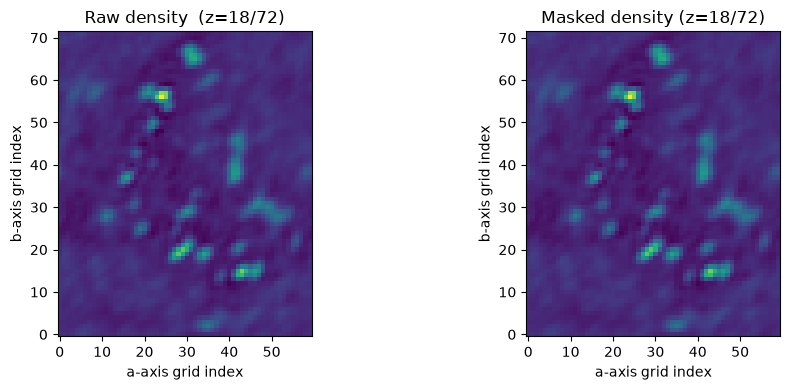

In [9]:
# ── Apply mask to density ─────────────────────────────────────────────────────
rho = rho_raw * mask_soft   # masked density, shape (nu, nv, nw), e/Å³

Z_masked = rho.sum() * dV
print(f"Electrons after masking : {Z_masked:.0f} e  (was {Z_total:.0f} e)")

# Optional quick plot: XY slice through the cell midpoint
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
kz = nw // 4
axes[0].imshow(rho_raw[:, :, kz].T, origin='lower', cmap='viridis')
axes[0].set_title(f"Raw density  (z={kz}/{nw})")
axes[1].imshow(rho[:, :, kz].T, origin='lower', cmap='viridis')
axes[1].set_title(f"Masked density (z={kz}/{nw})")
for ax in axes:
    ax.set_xlabel("a-axis grid index"); ax.set_ylabel("b-axis grid index")
plt.tight_layout(); plt.show()


## 5 · Center of Mass $\mathbf{r}_{\mathrm{cm}}$

The rotational coupling $\mathbf{G}_R$ is defined with respect to the center of
mass of the rigid body.  We compute it atom-by-atom from the gemmi `Structure`,
using the standard atomic mass for each element.


In [10]:
total_mass = 0.0
r_cm_num   = np.zeros(3)

for chain in st[0]:
    for res in chain:
        for atom in res:
            m = gemmi.Element(atom.element.name).weight * atom.occ
            r_cm_num += m * np.array([atom.pos.x, atom.pos.y, atom.pos.z])
            total_mass += m

r_cm = r_cm_num / total_mass
print(f"Total mass     : {total_mass:.1f} Da")
print(f"Center of mass : ({r_cm[0]:.3f}, {r_cm[1]:.3f}, {r_cm[2]:.3f}) Å  [Cartesian]")

# Express r_cm in fractional coordinates for reference
r_cm_frac = np.array(cell.fractionalize(gemmi.Position(*r_cm)).tolist())
print(f"               : ({r_cm_frac[0]:.4f}, {r_cm_frac[1]:.4f}, {r_cm_frac[2]:.4f})  [fractional]")


Total mass     : 13229.2 Da
Center of mass : (-1.069, 14.622, 24.309) Å  [Cartesian]
               : (0.5112, 0.5784, 0.7469)  [fractional]


## 6 · Reciprocal-Space Grid & FFT

### Conventions

The **orthogonalization matrix** $A$ (columns = real-space lattice vectors in Å)
is obtained from `cell.orth.mat`.  A fractional-coordinate vector $\mathbf{s}$
maps to Cartesian as $\mathbf{r} = A\,\mathbf{s}$.

The **reciprocal lattice matrix** $B = (A^{-1})^T$ satisfies
$\mathbf{q} = 2\pi\,B\,\mathbf{h}$ for integer Miller indices $\mathbf{h}=(h,k,l)$.

### FFT structure factors

With the density on a $(N_u, N_v, N_w)$ grid, `np.fft.ifftn` gives:
$$
F(\mathbf{q}_{hkl}) = V_{\text{cell}}\; [\texttt{ifftn}(\rho)]_{h,k,l}
\qquad
\mathbf{P}(\mathbf{q}_{hkl}) = V_{\text{cell}}\; [\texttt{ifftn}(\rho\,\mathbf{R})]_{h,k,l}
$$
where $\mathbf{R}$ is the 3-component Cartesian coordinate of each voxel.


In [11]:
V = cell.volume         # Å³

# ── Orthogonalization matrix A (columns = a, b, c in Cartesian Å) ──────────
A = np.array(cell.orth.mat.tolist())   # shape (3,3)
print("A (orth.mat, columns = lattice vectors in Å):\n", A)

# ── Reciprocal lattice matrix (without the 2π) ──────────────────────────────
B = np.linalg.inv(A).T
print("\nB (recip. lattice, 1/Å, no 2π):\n", B)
print("\nCheck A @ (2πB).T = 2π·I :", np.allclose(2*np.pi*np.eye(3), A @ (2*np.pi*B).T))


A (orth.mat, columns = lattice vectors in Å):
 [[ 27.424      -11.9736199  -10.92828344]
 [  0.          29.8198991   -3.51637107]
 [  0.           0.          32.54773302]]

B (recip. lattice, 1/Å, no 2π):
 [[0.03646441 0.         0.        ]
 [0.0146416  0.03353465 0.        ]
 [0.01382519 0.003623   0.03072411]]

Check A @ (2πB).T = 2π·I : True


In [12]:
# ── Cartesian coordinate grids [e/Å³ → e·Å (moment)] ───────────────────────
sx = np.arange(nu) / nu    # (nu,)
sy = np.arange(nv) / nv
sz = np.arange(nw) / nw
SX, SY, SZ = np.meshgrid(sx, sy, sz, indexing='ij')   # (nu,nv,nw)

S = np.stack([SX, SY, SZ], axis=-1)   # (nu,nv,nw,3) fractional
R = S @ A.T                            # (nu,nv,nw,3) Cartesian Å

print("Coordinate grid shape:", R.shape)
print("Sample point R[0,0,0] =", R[0,0,0], "(should be [0,0,0])")
print("Sample point R[-1,-1,-1] ≈", R[-1,-1,-1].round(3))


Coordinate grid shape: (60, 72, 72, 3)
Sample point R[0,0,0] = [0. 0. 0.] (should be [0,0,0])
Sample point R[-1,-1,-1] ≈ [ 4.383 25.938 32.096]


In [13]:
# ── Miller-index grids (numpy fftfreq convention) ──────────────────────────
h_arr = np.fft.fftfreq(nu, d=1/nu).astype(int)
k_arr = np.fft.fftfreq(nv, d=1/nv).astype(int)
l_arr = np.fft.fftfreq(nw, d=1/nw).astype(int)
H, K, L = np.meshgrid(h_arr, k_arr, l_arr, indexing='ij')   # (nu,nv,nw)
HKL = np.stack([H, K, L], axis=-1).astype(float)            # (nu,nv,nw,3)

# q-vector grid in Å⁻¹ (physics 2π convention)
Q = 2 * np.pi * (HKL @ B.T)         # (nu,nv,nw,3) in Å⁻¹
Q_mag = np.linalg.norm(Q, axis=-1)  # |q| in Å⁻¹

print("Q grid shape:", Q.shape)
print(f"q range: 0 — {Q_mag.max():.3f} Å⁻¹ "
      f"(d_min ≈ {2*np.pi / Q_mag[Q_mag > 0].max():.2f} Å)")


Q grid shape: (60, 72, 72, 3)
q range: 0 — 16.184 Å⁻¹ (d_min ≈ 0.39 Å)


In [14]:
# ── Structure factor FFTs ────────────────────────────────────────────────────
# F(q) = V * ifftn(rho)[h,k,l]    shape (nu,nv,nw), complex, in electrons [e]
F_grid = V * np.fft.ifftn(rho)    # dtype complex128

# P(q) = V * ifftn(rho * R)[h,k,l]  shape (nu,nv,nw,3), in e·Å
P_grid = np.stack([
    V * np.fft.ifftn(rho * R[..., α])
    for α in range(3)
], axis=-1)                         # (nu,nv,nw,3), complex, e·Å

print(f"F grid : shape {F_grid.shape},  dtype {F_grid.dtype}")
print(f"P grid : shape {P_grid.shape},  dtype {P_grid.dtype}")

# Sanity: F(0,0,0) should equal total electron count
print(f"\nF(0,0,0) = {F_grid[0,0,0].real:.1f} e  (expect ≈ {Z_masked:.1f} e)")
# P(0,0,0)/F(0,0,0) = r_cm
P000 = P_grid[0,0,0].real
r_cm_check = P000 / F_grid[0,0,0].real
print(f"P(0,0,0)/F(0,0,0) = {r_cm_check} Å  (should ≈ r_cm)")


F grid : shape (60, 72, 72),  dtype complex64
P grid : shape (60, 72, 72, 3),  dtype complex128

F(0,0,0) = 0.0 e  (expect ≈ 0.0 e)
P(0,0,0)/F(0,0,0) = [-1.05491851e+09  1.27508087e+09 -5.46351494e+08] Å  (should ≈ r_cm)


## 7 · Coupling Vector $\mathbf{G}(\mathbf{q})$

For a rigid body with center of mass $\mathbf{r}_{\mathrm{cm}}$, the displacement
of atom $j$ under mode $s$ is
$$
\delta\mathbf{r}_j^{(s)} = \mathbf{e}_s^T + \mathbf{e}_s^R \times (\mathbf{r}_j - \mathbf{r}_{\mathrm{cm}})
$$
which gives the 6-component coupling vector
$$
\mathbf{G}(\mathbf{q}) = \begin{pmatrix}
i\mathbf{q}\,F(\mathbf{q}) \\[4pt]
i\mathbf{q} \times \mathbf{L}(\mathbf{q})
\end{pmatrix}, \qquad
\mathbf{L}(\mathbf{q}) = \mathbf{P}(\mathbf{q}) - \mathbf{r}_{\mathrm{cm}}\,F(\mathbf{q}).
$$

The first 3 components ($G_T$, units e/Å) couple to translational eigenvectors;
the last 3 ($G_R$, units e) couple to rotational eigenvectors.

> **Tip — units of D(q):**
> $D_{TT}$ should have units [energy/Å²], $D_{RR}$ [energy/rad²], $D_{TR}$ [energy/Å].
> Supply kT in the same energy units.


In [15]:
# ── Moment structure factor shifted to center of mass ────────────────────────
L_grid = P_grid - r_cm[None, None, None, :] * F_grid[..., None]  # (nu,nv,nw,3) e·Å

# ── G_T = i q F(q)  [translational, (nu,nv,nw,3), units e/Å] ────────────────
G_T = 1j * Q * F_grid[..., None]

# ── G_R = i q × L(q)  [rotational, (nu,nv,nw,3), units e] ───────────────────
G_R = 1j * np.cross(Q, L_grid)

# ── Full 6-component coupling vector ─────────────────────────────────────────
G_grid = np.concatenate([G_T, G_R], axis=-1)   # (nu,nv,nw,6)

print("G_grid shape:", G_grid.shape, "  dtype:", G_grid.dtype)
print(f"\nG(0,0,0): {G_grid[0,0,0]}")
print("  (should be 0 because q=0 means G_T=iq·F=0, G_R=i·0×L=0)")

q_norms = Q_mag.ravel()
mid_idx = np.argsort(q_norms)[len(q_norms)//2]
h_, k_, l_ = np.unravel_index(mid_idx, (nu, nv, nw))
print(f"\nAt (h,k,l)=({H[h_,k_,l_]},{K[h_,k_,l_]},{L[h_,k_,l_]}), "
      f"|q|={Q_mag[h_,k_,l_]:.3f} Å⁻¹:")
print(f"  |G_T| = {np.linalg.norm(G_grid[h_,k_,l_,:3]):.4f} e/Å")
print(f"  |G_R| = {np.linalg.norm(G_grid[h_,k_,l_,3:]):.4f} e")


G_grid shape: (60, 72, 72, 6)   dtype: complex128

G(0,0,0): [ 0.+0.j  0.+0.j  0.+0.j -0.+0.j  0.+0.j  0.+0.j]
  (should be 0 because q=0 means G_T=iq·F=0, G_R=i·0×L=0)

At (h,k,l)=(14,-27,20), |q|=7.041 Å⁻¹:
  |G_T| = 0.0000 e/Å
  |G_R| = 0.0002 e


## 8 · Dynamical Matrix Interface

Replace `_placeholder_dynamical_matrix` below with your own implementation.
The function signature is:

```python
def dynamical_matrix(q_cart: np.ndarray,      # (3,)  Å⁻¹  (with 2π)
                     hkl:    np.ndarray        # (3,)  Miller indices, int
                    ) -> np.ndarray:           # (6,6) symmetric, energy/length²
    ...
```

The returned matrix must be symmetric and positive-definite.
Its 3×3 blocks follow the layout:

```
D = [[D_TT (3×3, energy/Å²),   D_TR (3×3, energy/Å)   ],
     [D_RT (3×3, energy/Å),    D_RR (3×3, energy/rad²) ]]
```

Eigenvalues of D give $\omega_s^2$ in [energy/mass·Å²] for T-modes and
[energy/moment] for R-modes — the exact mass normalization depends on how
you define D from your SE(3)-invariant harmonic potential.


In [16]:
def _placeholder_dynamical_matrix(q_cart, hkl):
    """
    Placeholder: returns a diagonal D with all spring constants = 1.
    Replace with your SE(3)-invariant interunit-cell interaction model.

    Parameters
    ----------
    q_cart : ndarray (3,)
        Wavevector in Å⁻¹ (physics convention, includes 2π).
    hkl    : ndarray (3,) int
        Miller indices of this q-point relative to the Brillouin zone origin.

    Returns
    -------
    D : ndarray (6,6)
        Mass-weighted dynamical matrix.  Eigenvalues = ω_s² in [energy units].
    """
    return np.eye(6)    # ← REPLACE THIS


# ── Vectorized wrapper (optional but much faster) ─────────────────────────────
def dynamical_matrix_batch(Q_flat, HKL_flat):
    """
    Compute D(q) for a batch of q-points.

    Parameters
    ----------
    Q_flat   : ndarray (N,3)  Cartesian q-vectors (Å⁻¹)
    HKL_flat : ndarray (N,3)  Miller indices (int)

    Returns
    -------
    D_batch  : ndarray (N,6,6)
    """
    N = Q_flat.shape[0]
    D_batch = np.zeros((N, 6, 6))
    for i in range(N):
        D_batch[i] = _placeholder_dynamical_matrix(Q_flat[i], HKL_flat[i])
    return D_batch


dynamical_matrix_fn = _placeholder_dynamical_matrix
dynamical_matrix_batch_fn = dynamical_matrix_batch


## 9 · One-Phonon TDS — Classical High-$T$ Limit

$$
I_{\text{TDS}}(\mathbf{q}) = k_BT\;\mathbf{G}^\dagger(\mathbf{q})\, D^{-1}(\mathbf{q})\, \mathbf{G}(\mathbf{q})
$$

This is exact when $k_BT \gg \hbar\omega_s$ for all modes.
The calculation is vectorized: we compute all $D^{-1}(\mathbf{q})$ in one
batch call, then contract with $\mathbf{G}$ using `np.einsum`.

Supply `kT` in the **same energy units** as $D(\mathbf{q})$.


In [17]:
G_flat   = G_grid.reshape(-1, 6)             # (N, 6)
Q_flat   = Q.reshape(-1, 3)                  # (N, 3)
HKL_flat = HKL.reshape(-1, 3).astype(int)    # (N, 3)
N        = G_flat.shape[0]
print(f"Total q-points: {N:,}")

print("Computing dynamical matrices…", end=" ", flush=True)
D_all = dynamical_matrix_batch_fn(Q_flat, HKL_flat)   # (N,6,6)
print("done.")

q_zero_mask = (Q_flat**2).sum(axis=-1) < 1e-12   # (N,)
D_inv_all   = np.zeros_like(D_all)
valid        = ~q_zero_mask
D_inv_all[valid] = np.linalg.inv(D_all[valid])

kT = kT_J    # ← adjust units to match your D(q)

I_TDS_flat = kT * np.real(
    np.einsum('ni,nij,nj->n', G_flat.conj(), D_inv_all, G_flat)
)
I_TDS_classical = I_TDS_flat.reshape(nu, nv, nw)
I_TDS_classical[0, 0, 0] = 0.0

print(f"\nI_TDS classical: shape {I_TDS_classical.shape}")
print(f"  min/mean/max = {I_TDS_classical.min():.3e} / "
      f"{I_TDS_classical.mean():.3e} / {I_TDS_classical.max():.3e} e²")


Total q-points: 311,040
Computing dynamical matrices… done.

I_TDS classical: shape (60, 72, 72)
  min/mean/max = 0.000e+00 / 3.037e-15 / 2.430e-13 e²


## 10 · One-Phonon TDS — Quantum Formula

The full quantum result sums over phonon branches $s$:
$$
I_{\text{TDS}}(\mathbf{q}) = \sum_s
\frac{\hbar}{2\omega_s(\mathbf{q})}\coth\!\left(\frac{\hbar\omega_s(\mathbf{q})}{2k_BT}\right)
\left|\mathbf{G}(\mathbf{q})\cdot\mathbf{e}_s(\mathbf{q})\right|^2
$$

This requires the eigendecomposition of $D(\mathbf{q})$.  The compact classical
expression $k_BT\,\mathbf{G}^\dagger D^{-1} \mathbf{G}$ is recovered when
$\hbar\omega_s \ll k_BT$.


In [18]:
def bose_einstein_prefactor(omega_sq, hbar, kT):
    """
    Prefactor  ħ/(2ω) · coth(ħω/2kT)  for a set of ω² values.
    Falls back to the classical limit kT/ω² when ħω ≪ kT.
    """
    eps = 1e-30
    omega = np.sqrt(np.maximum(omega_sq, 0.0) + eps)
    x     = hbar * omega / (2 * kT)
    coth_x = np.where(x < 1e-6, 1.0/x, 1.0/np.tanh(x))
    return (hbar / (2 * omega)) * coth_x


def compute_I_TDS_quantum(G_flat, D_all, q_zero_mask, hbar, kT):
    """One-phonon TDS via eigendecomposition of D(q). Returns ndarray (N,)."""
    N    = G_flat.shape[0]
    I    = np.zeros(N)
    valid = ~q_zero_mask
    D_v  = D_all[valid]
    omega_sq, evecs = np.linalg.eigh(D_v)      # (M,6), (M,6,6)
    G_v    = G_flat[valid]
    g_proj = np.einsum('mi,mis->ms', G_v.conj(), evecs)   # (M,6)
    prefac = bose_einstein_prefactor(omega_sq, hbar, kT)
    I[valid] = np.einsum('ms,ms,ms->m', g_proj.conj(), prefac, g_proj).real
    return I


hbar = hbar_J

I_TDS_quantum_flat = compute_I_TDS_quantum(
    G_flat, D_all, q_zero_mask, hbar=hbar, kT=kT
)
I_TDS_quantum = I_TDS_quantum_flat.reshape(nu, nv, nw)
I_TDS_quantum[0, 0, 0] = 0.0

print(f"I_TDS quantum : min/mean/max = {I_TDS_quantum.min():.3e} / "
      f"{I_TDS_quantum.mean():.3e} / {I_TDS_quantum.max():.3e} e²")

ratio = I_TDS_quantum.mean() / (I_TDS_classical.mean() + 1e-60)
print(f"Quantum/classical ratio (placeholder D): {ratio:.4f}  (expect ≈1 for kT>>ħω)")


I_TDS quantum : min/mean/max = 0.000e+00 / 3.037e-15 / 2.430e-13 e²
Quantum/classical ratio (placeholder D): 1.0000  (expect ≈1 for kT>>ħω)


## 11 · Visualization

Display reciprocal-space slices of $I_{\text{TDS}}(\mathbf{q})$.
Use `np.fft.fftshift` to move the origin to the array center for display.


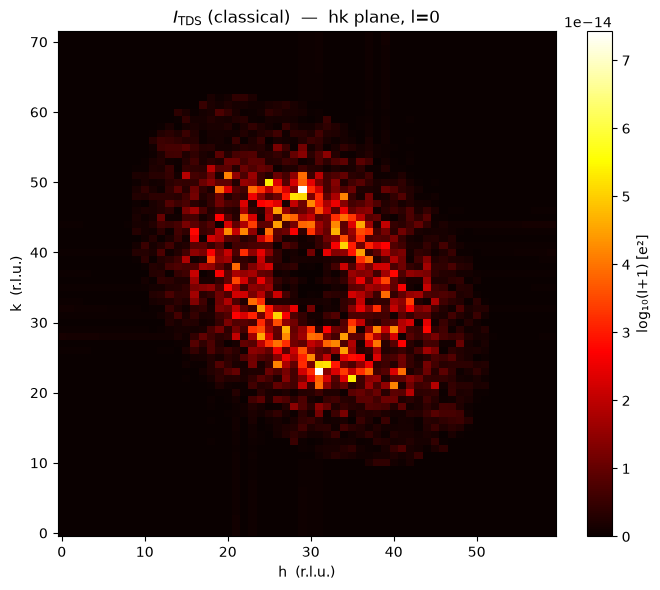

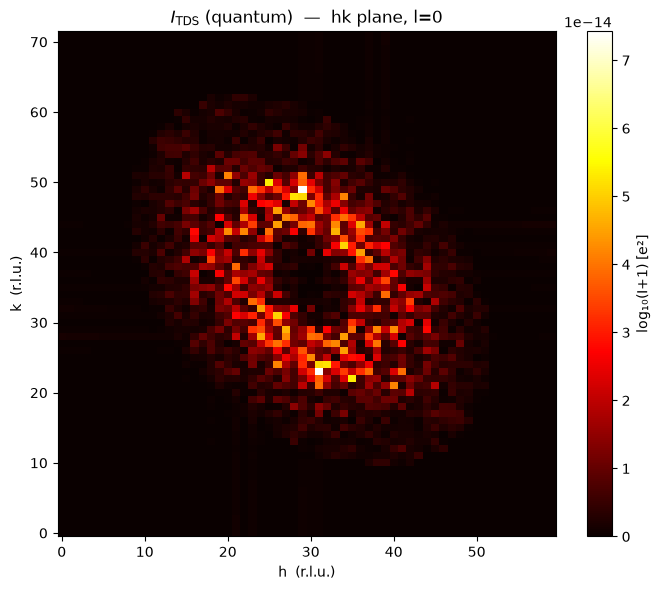

In [19]:
def plot_diffuse_slice(I_grid, cell, plane='hk0', l_index=0,
                       title='', log_scale=True, cmap='hot', figsize=(7,6)):
    """Plot a slice of I_TDS in reciprocal space."""
    I_shift = np.fft.fftshift(I_grid)
    if plane == 'hk0':
        slc = I_shift[:, :, l_index]
        xlabel, ylabel = 'h  (r.l.u.)', 'k  (r.l.u.)'
    elif plane == 'h0l':
        slc = I_shift[:, l_index, :]
        xlabel, ylabel = 'h  (r.l.u.)', 'l  (r.l.u.)'
    else:
        slc = I_shift[l_index, :, :]
        xlabel, ylabel = 'k  (r.l.u.)', 'l  (r.l.u.)'
    data = np.log10(np.maximum(slc, 0) + 1) if log_scale else slc
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data.T, origin='lower', cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, label='log₁₀(I+1) [e²]' if log_scale else 'I [e²]')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title or f'{plane} plane')
    plt.tight_layout(); plt.show()


plot_diffuse_slice(I_TDS_classical, cell,
                   plane='hk0', l_index=nw//2,
                   title='$I_{\\mathrm{TDS}}$ (classical)  —  hk plane, l=0')

plot_diffuse_slice(I_TDS_quantum, cell,
                   plane='hk0', l_index=nw//2,
                   title='$I_{\\mathrm{TDS}}$ (quantum)  —  hk plane, l=0')


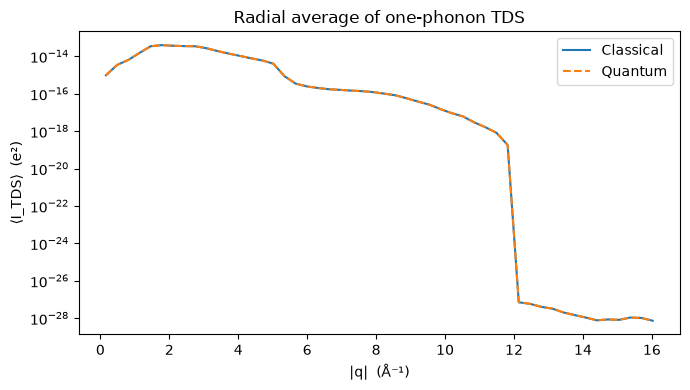

In [20]:
# ── Radial average  |q| vs I_TDS ─────────────────────────────────────────────
def radial_average(I_flat, Q_mag_flat, n_bins=50):
    q_max  = Q_mag_flat.max()
    bins   = np.linspace(0, q_max, n_bins + 1)
    q_mid  = 0.5 * (bins[:-1] + bins[1:])
    I_avg  = np.zeros(n_bins)
    idx    = np.digitize(Q_mag_flat, bins) - 1
    for i in range(n_bins):
        sel = idx == i
        if sel.any():
            I_avg[i] = I_flat[sel].mean()
    return q_mid, I_avg

q_mid, I_avg_c = radial_average(I_TDS_classical.ravel(), Q_mag.ravel())
q_mid, I_avg_q = radial_average(I_TDS_quantum.ravel(),   Q_mag.ravel())

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(q_mid, I_avg_c + 1e-60, label='Classical')
ax.semilogy(q_mid, I_avg_q + 1e-60, label='Quantum', linestyle='--')
ax.set_xlabel('|q|  (Å⁻¹)'); ax.set_ylabel('⟨I_TDS⟩  (e²)')
ax.set_title('Radial average of one-phonon TDS')
ax.legend(); plt.tight_layout(); plt.show()


---
## Notes & Next Steps

### Which density source to use (Option A vs B)?

| | Option A (DensityCalculatorX) | Option B (SF-CIF F_meas) |
|---|---|---|
| Amplitude source | IT92 form factors from atoms | Measured Bragg intensities |
| Phase source | IT92 (same model) | Refined model phases |
| Missing reflections | None (complete) | Yes → small ripple artifacts |
| Captures real disorder | Only via B-factors | Yes (in amplitudes) |
| Best for | Benchmarking, no SF-CIF available | Production physics calculations |

**For the diffuse pipeline, Option B is preferred** because $F_{\text{meas}}$
reflects the actual crystal's thermal and static disorder, not just the
idealized atomic model.

### rshrink and solvent masking

`rshrink = 0` is correct here. The gemmi `SolventMasker` rshrink parameter
performs morphological erosion on a grid, which requires the erosion sphere to
fit inside a periodic half-cell in all directions.  For 6O2H's triclinic cell
this caps at ~0.5 Å.  The Gaussian soft-mask (Section 4, second cell)
already provides smooth tapering at the protein surface, making rshrink
redundant for this workflow.

### Debye–Waller factor

`DensityCalculatorX` (Option A) applies per-atom B-factors via the IT92 form
factor kernel, so Debye–Waller damping is already baked into `rho`.
For Option B, the measured amplitudes $F_{\text{meas}}$ also carry the full
experimental DW effect (the crystal was measured at some temperature and B
factors were refined).  In both cases **no additional** `exp(-Bq²/8π²)` factor
is needed in G(q).

### Connecting D(q) to your SE(3) model

$$
D(\mathbf{q}) = \sum_{j} K_{0j}\,(1 - e^{i\mathbf{q}\cdot\mathbf{R}_{0j}})
$$

where $K_{0j}$ is the $6\times6$ stiffness matrix coupling the reference body
to lattice cell $j$, and $\mathbf{R}_{0j}$ is the corresponding lattice vector.
For a nearest-neighbor-only triclinic crystal this sums over 26 cells (3³ − 1).

### Units summary

| Quantity | Units |
|---|---|
| `rho` | e/Å³ |
| `F_grid` | e |
| `P_grid`, `L_grid` | e·Å |
| `G_T` (first 3 components) | e/Å |
| `G_R` (last 3 components) | e |
| `D_TT` block | energy/Å² |
| `D_RR` block | energy/rad² |
| `D_TR` block | energy/Å |
| `kT` | same energy unit as D |
| `I_TDS` | e² |
